# Matrix Experimentation Walkthrough
This notebook demonstrates how to use the library to generate, sparsify, and visualize adjacency matrices for time series data.


## 1. Setup and Imports


In [6]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add src to path
sys.path.append('../src')

from matrix_generation import PearsonCorrelationGenerator
from sparcification import MatrixConstructionPipeline, TopKRowSparsifier, RowL1Normalizer
from utils.visualization import plot_adjacency_matrix_heatmap, plot_node_time_series


## 2. Load Data
We'll use a small synthetic dataset for this example.


In [7]:
from data.loaders import load_gaussian_data
data, _ = load_gaussian_data(n_nodes=10, n_timesteps=100)
print(f"Data shape: {data.shape}")  # [L, N, C]


Data shape: (100, 10, 1)


## 3. Visualize a Time Series


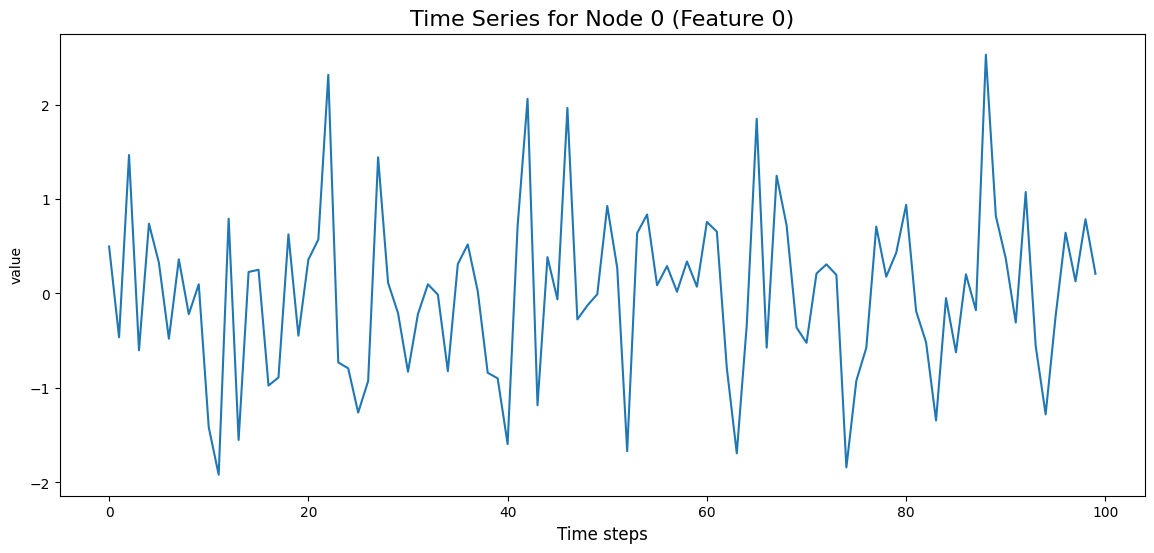

In [8]:
plot_node_time_series(data, node_index=0, show=True)


## 4. Generate Correlation Matrix


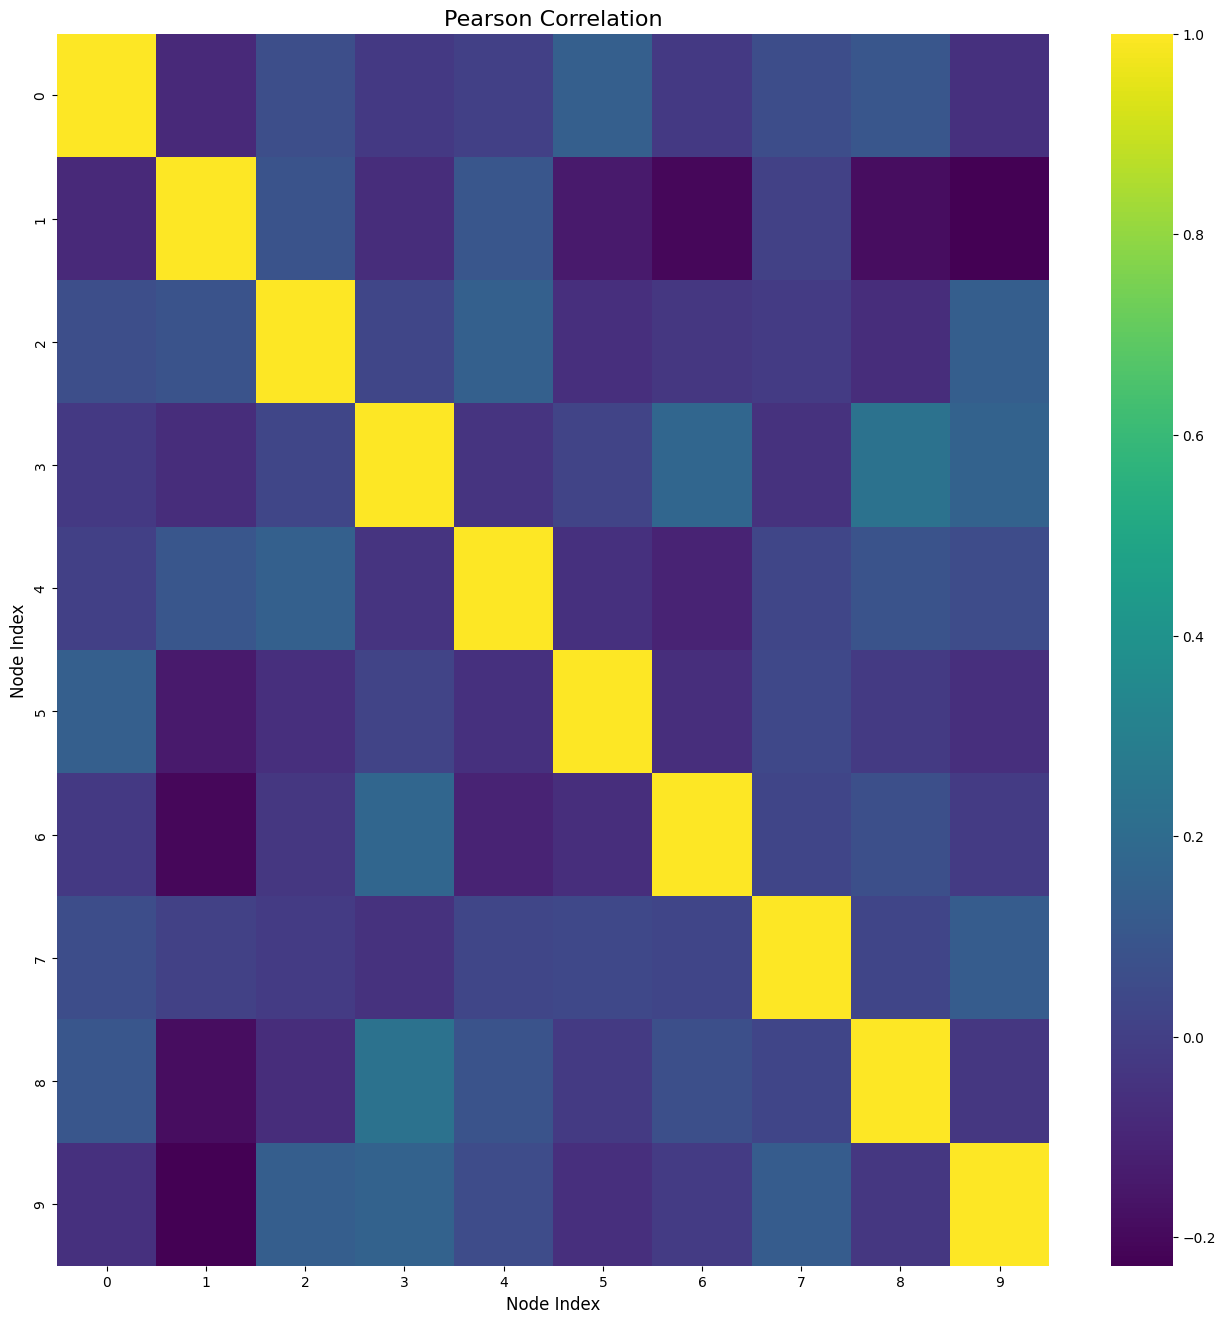

In [9]:
generator = PearsonCorrelationGenerator()
sim_matrix = generator.generate(data)
plot_adjacency_matrix_heatmap(sim_matrix, title="Pearson Correlation")


## 5. Sparsify and Normalize
We use the `MatrixConstructionPipeline` to keep only the top 3 neighbors for each node and then normalize rows.


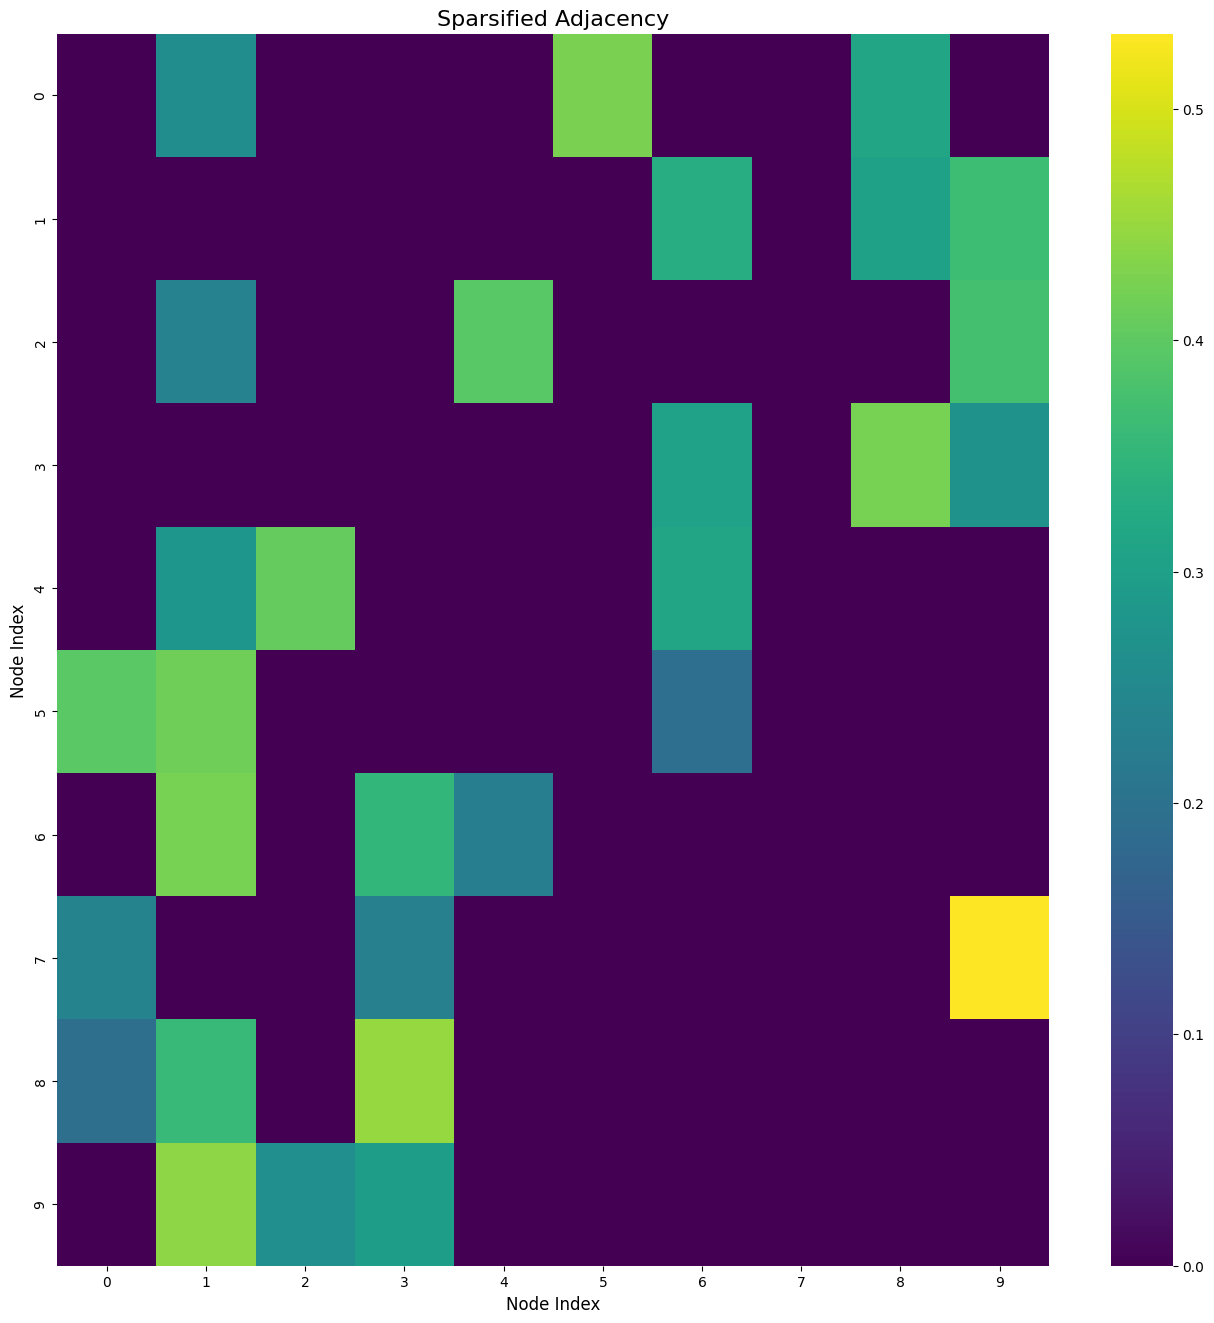

In [10]:
pipeline = MatrixConstructionPipeline(
    sparsifiers=[TopKRowSparsifier(k_per_node=3)],
    normalizers=[RowL1Normalizer()]
)
adj_matrix = pipeline.run(sim_matrix, k=30)
plot_adjacency_matrix_heatmap(adj_matrix, title="Sparsified Adjacency")


## 6. Graph Metrics


In [11]:
from utils.graph_metrics import calculate_graph_metrics
metrics = calculate_graph_metrics(adj_matrix, directed=True)
for k, v in metrics.items():
    print(f"{k:25}: {v}")


num_nodes                : 10
total_edges              : 30
density                  : 0.3333333333333333
sparsity                 : 0.7
avg_connection_strength  : 0.3333333432674408
clustering_coefficient   : 0.0125
algebraic_connectivity   : 0.49951305985450745
spectral_gap             : 0.49951308965682983
num_components           : 2
is_connected             : True
min_degree               : 3
max_degree               : 10
mean_degree              : 6.0
median_degree            : 6.0
mode_degree              : 7
std_degree               : 1.8439088914585775
q1_degree                : 5.0
q3_degree                : 7.0
reciprocity              : 0.36666666666666664
mean_in_degree           : 3.0
mean_out_degree          : 3.0
